# 02 — Subtopic Classification via BERTopic Clustering

Discovers 10–20 AI subtopics **data-driven** (no predefined keywords) using:
1. Sentence-BERT embeddings (`all-mpnet-base-v2` — 768-dim, 12-layer)
2. UMAP dimensionality reduction → 10D
3. HDBSCAN density clustering → auto topic count
4. BERTopic c-TF-IDF for human-readable topic labels
5. **Soft / multi-label assignment** — every article is assigned to its top-k
   probable topics (k ≥ 1) via approximate cosine similarity to topic centroids,
   so one article can carry multiple subtopic labels.

Input : `data/raw_articles.csv`  
Output: `data/classified_articles.csv`  
Side  : `data/topic_info.csv`, `data/embeddings.npy` (cached)

> **Model note:** `all-mpnet-base-v2` (768-dim) replaces the previous `all-MiniLM-L6-v2`
> (384-dim). The higher dimensionality gives UMAP and HDBSCAN far more signal to separate
> 10–20 distinct AI subtopics. One-time encode cost: ~3–4 h on CPU, ~30 min on GPU.
> After that it reads from the cache and is instant.

In [1]:
# pip install sentence-transformers bertopic umap-learn hdbscan scikit-learn
import pandas as pd
import numpy as np
import warnings, os
warnings.filterwarnings('ignore')

df = pd.read_csv('data/raw_articles.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} articles')
df.head(2)

Loaded 37,259 articles


,id,date,section,headline,body,wordcount,url,topics,topic_count,primary_topic
0,business/2026/mar/02/middle-east-crisis-oil-pr...,2026-03-02,Business,Middle East crisis pushes up oil prices – and ...,The impact of the deadly and unpredictable con...,684,https://www.theguardian.com/business/2026/mar/...,ai|geopolitics_conflict|energy_markets|macroec...,6,ai
1,world/2026/apr/08/will-shipping-in-the-strait-...,2026-04-08,World news,Will shipping in the strait of Hormuz – and oi...,"If the US-Israeli ceasefire with Iran holds, i...",1361,https://www.theguardian.com/world/2026/apr/08/...,geopolitics_conflict|energy_markets|public_health,3,geopolitics_conflict


## Step 1 — Prepare Text
Use headline + first 512 chars of body. Keeps context rich enough for embeddings
without slowing encode time.

In [2]:
df['text_input'] = (
    df['headline'].fillna('') + '. ' +
    df['body'].fillna('').str[:512]
)
df = df[df['text_input'].str.len() > 30].reset_index(drop=True)
print(f'Articles after quality filter: {len(df):,}')

Articles after quality filter: 37,259


## Step 2 — Embed with Sentence-Transformers

**Model: `all-mpnet-base-v2`** (768-dim, 12 Transformer layers, ~420 MB)  
- ~3–4 h on CPU for 23k articles (one-time); ~30 min on GPU
- 2× the embedding dimensions of MiniLM-L6 → much richer semantic space for UMAP/HDBSCAN
- Embeddings cached to `data/embeddings.npy` — subsequent runs load instantly

> **Important:** The cache is model-specific. If you switch models, delete
> `data/embeddings.npy` first, otherwise the dim-assertion below will catch it.

In [3]:
from sentence_transformers import SentenceTransformer

EMBED_MODEL = 'all-mpnet-base-v2'   # 768-dim, 12-layer
EMBED_CACHE = 'data/embeddings.npy'

if os.path.exists(EMBED_CACHE):
    embeddings = np.load(EMBED_CACHE)
    print(f'Loaded cached embeddings: {embeddings.shape}')
    assert len(embeddings) == len(df), (
        f'Cache size mismatch ({len(embeddings)} vs {len(df)} articles). '
        'Delete data/embeddings.npy and re-run.'
    )
    assert embeddings.shape[1] == 768, (
        f'Expected 768-dim embeddings for {EMBED_MODEL}, got {embeddings.shape[1]}. '
    )
else:
    print(f'Encoding {len(df):,} articles with {EMBED_MODEL}...')
    print('Expected time: ~1–2 h on CPU, ~2 min on APPLE M4. Grab a coffee.')
    model = SentenceTransformer(EMBED_MODEL)
    embeddings = model.encode(
        df['text_input'].tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(EMBED_CACHE, embeddings)
    print(f'Embeddings saved → {EMBED_CACHE}  shape: {embeddings.shape}')

Encoding 37,259 articles with all-mpnet-base-v2...
Expected time: ~1–2 h on CPU, ~2 min on APPLE M4. Grab a coffee.


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Batches: 100%|██████████| 1165/1165 [33:25<00:00,  1.72s/it]


Embeddings saved → data/embeddings.npy  shape: (37259, 768)


## Step 3 — BERTopic: Discover 10–20 Topics

Key hyperparameters (tuned for 768-dim mpnet embeddings + ~23k docs):

| Param | Value | Rationale |
|---|---|---|
| `MIN_CLUSTER_SIZE` | ~48 (0.2% of corpus) | Was ~120 (0.5%) → was too coarse, merging distinct subtopics |
| `n_components` (UMAP) | 10 | Was 5 → preserves more structure from 768-dim space before clustering |
| `min_samples` (HDBSCAN) | 5 | Was 10 → allows detection of smaller, tighter topic clusters |
| `min_df` (vectorizer) | 0.3% | Was 0.5% → includes slightly rarer but topically meaningful terms |
| `NR_TOPICS` | `'auto'` | BERTopic merges near-duplicate topics automatically |

**If you get < 10 topics:** lower `MIN_CLUSTER_SIZE` (try `len(df) // 700`)  
**If you get > 20 topics:** set `NR_TOPICS = 15` to force merging  
**Outlier topic -1** is reassigned in Step 5 via centroid similarity — don't worry about it here

In [8]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ── Tunable knobs ────────────────────────────────────────────
MIN_CLUSTER_SIZE = 120   # ~4 for 4k docs (0.2% of corpus)
NR_TOPICS        = 'auto'  # BERTopic auto-merges near-duplicate topics
#   → If result < 10 topics: lower to max(30, len(df) // 700)
#   → If result > 20 topics: set NR_TOPICS = 15 to force merging
# ─────────────────────────────────────────────────────────────

umap_model = UMAP(
    n_components=10,     # 5→10: preserves more structure from 768-dim embeddings
    n_neighbors=15,      # local connectivity — good balance for 23k docs
    min_dist=0.0,        # keep tight for density-based downstream clustering
    metric='cosine',
    random_state=42,
)

hdbscan_model = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=5,       # 10→5: detects smaller, tighter topic clusters
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,   # required for soft-clustering in Step 5
)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=0.003,        # 0.5%→0.3%: slightly rarer but topically meaningful terms
    max_df=0.90,
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=NR_TOPICS,
    top_n_words=12,
    verbose=True,
)

topics, probs = topic_model.fit_transform(
    df['text_input'].tolist(),
    embeddings=embeddings,   # reuse precomputed 768-dim embeddings
)

df['topic_id'] = topics

topic_info = topic_model.get_topic_info()
n_real    = (topic_info['Topic'] >= 0).sum()
n_outlier = (df['topic_id'] == -1).sum()
print(f'\nTopics found: {n_real}  |  Outlier articles (topic -1): {n_outlier:,}')
print(f'(Target: 10–20 topics. Adjust MIN_CLUSTER_SIZE if outside range.)\n')
topic_info

2026-04-20 00:41:09,329 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
2026-04-20 00:42:05,303 - BERTopic - Dimensionality - Completed ✓
2026-04-20 00:42:05,313 - BERTopic - Cluster - Start clustering the reduced embeddings
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenize


Topics found: 23  |  Outlier articles (topic -1): 9,274
(Target: 10–20 topics. Adjust MIN_CLUSTER_SIZE if outside range.)



,Topic,Count,Name,Representation,Representative_Docs
0,-1,9274,-1_climate_australia_australian_trumps,"[climate, australia, australian, trumps, feder...",[Peter Dutton to promise Australia will boost ...
1,0,17632,0_gaza_israel_israeli_iran,"[gaza, israel, israeli, iran, donald trump, tr...",[Israel denies its forces are storming al-Amal...
2,1,2237,1_ukraine_russian_russia_ukrainian,"[ukraine, russian, russia, ukrainian, zelensky...",[Russia-Ukraine war: Kyiv and Kharkiv under mi...
3,2,2049,2_ai_artificial_artificial intelligence_intell...,"[ai, artificial, artificial intelligence, inte...",[Elon Musk’s startup rolls out new Grok-3 chat...
4,3,1562,3_weather_temperatures_flooding_rain,"[weather, temperatures, flooding, rain, heatwa...",[Some NSW flood warnings remain but relief for...
5,4,506,4_sales_retail_food_prices,"[sales, retail, food, prices, price, retailers...",[Retail sales rise unexpectedly in Great Brita...
6,5,496,5_venezuela_maduro_nicols_president,"[venezuela, maduro, nicols, president, nicols ...",[Russia and China pledge support for Venezuela...
7,6,373,6_police_man_murder_died,"[police, man, murder, died, woman, killed, inq...",[Man shot dead by police in Potts Point after ...
8,7,363,7_china_chinese_chinas_xi,"[china, chinese, chinas, xi, beijing, xi jinpi...",[First Thing: China raises tariffs on US impor...
9,8,288,8_oil_prices_fuel_iran,"[oil, prices, fuel, iran, petrol, oil prices, ...",[UK petrol prices poised to fall further as oi...


In [9]:
# Print top keywords per topic for manual review
print('=== Topic Keyword Summary ===')
for _, row in topic_info[topic_info['Topic'] >= 0].iterrows():
    tid   = row['Topic']
    count = row['Count']
    words = topic_model.get_topic(tid)
    kw    = ', '.join(w for w, _ in words[:8])
    print(f'  Topic {tid:3d} ({count:5,} docs): {kw}')

=== Topic Keyword Summary ===
  Topic   0 (17,632 docs): gaza, israel, israeli, iran, donald trump, trumps, president, hamas
  Topic   1 (2,237 docs): ukraine, russian, russia, ukrainian, zelenskyy, putin, ukraine war, kyiv
  Topic   2 (2,049 docs): ai, artificial, artificial intelligence, intelligence, chatgpt, openai, technology, company
  Topic   3 (1,562 docs): weather, temperatures, flooding, rain, heatwave, floods, climate, heat
  Topic   4 (  506 docs): sales, retail, food, prices, price, retailers, shoppers, inflation
  Topic   5 (  496 docs): venezuela, maduro, nicols, president, nicols maduro, venezuelas, venezuelan, oil
  Topic   6 (  373 docs): police, man, murder, died, woman, killed, inquest, officer
  Topic   7 (  363 docs): china, chinese, chinas, xi, beijing, xi jinping, jinping, taiwan
  Topic   8 (  288 docs): oil, prices, fuel, iran, petrol, oil prices, barrel, crude
  Topic   9 (  288 docs): vaccine, kennedy, jr, vaccines, cdc, robert kennedy, robert, kennedy jr
  

## Step 4 — Name the Topics

Review the keyword summary above, then fill `TOPIC_NAME_MAP` below.  
- Use descriptive names (they become subtopic labels in all downstream notebooks)
- Topics you want to **discard** (noise, off-topic): map to `None`
- Leave `-1` as `'Unclassified'` — it will be reassigned by centroid similarity next

In [11]:
# ── EDIT THIS after reviewing keywords above ─────────────────
# Example mapping — update IDs and names to match your run.
TOPIC_NAME_MAP = {
    0:  'Middle East Conflict',
    1:  'Russia-Ukraine War',
    2:  'AI & OpenAI',
    3:  'Weather & Climate',
    4:  'Retail Prices & Inflation',
    5:  'Venezuela Politics & Oil',
    6:  'Crime & Policing',
    7:  'China & Taiwan',
    8:  'Oil & Fuel Prices',
    9:  'Vaccines & RFK Jr',
    10: 'Biodiversity & Wildlife',
    11: 'Cybersecurity & Data Breaches',
    12: 'Australian War Crimes Case',
    13: 'Farming & Inheritance Tax',
    14: 'Education & Student Loans',
    15: 'Water Utilities & Sewage',
    16: 'Amazon Rainforest & Drought',
    17: 'Electric Vehicles & Auto Industry',
    18: 'Marine Ecosystems',
    19: 'Vatican & Papacy',
    20: 'French Politics',
    21: 'Myanmar & Bangladesh Politics',
    22: 'Airlines & Flights',
    -1: 'Others'
}
# Any topic_id not listed above will be labelled 'Cluster_<id>'
# ─────────────────────────────────────────────────────────────

def lookup_name(tid):
    if tid in TOPIC_NAME_MAP:
        return TOPIC_NAME_MAP[tid]   # may be None
    return f'Cluster_{tid}'

df['subtopic_primary'] = df['topic_id'].apply(lookup_name)
print('Primary assignment (before multi-label & outlier fix):')
print(df['subtopic_primary'].value_counts())

Primary assignment (before multi-label & outlier fix):
subtopic_primary
Middle East Conflict                 17632
Others                                9274
Russia-Ukraine War                    2237
AI & OpenAI                           2049
Weather & Climate                     1562
Retail Prices & Inflation              506
Venezuela Politics & Oil               496
Crime & Policing                       373
China & Taiwan                         363
Oil & Fuel Prices                      288
Vaccines & RFK Jr                      288
Biodiversity & Wildlife                265
Cybersecurity & Data Breaches          235
Australian War Crimes Case             216
Farming & Inheritance Tax              198
Education & Student Loans              178
Water Utilities & Sewage               156
Amazon Rainforest & Drought            155
Electric Vehicles & Auto Industry      151
Marine Ecosystems                      132
Vatican & Papacy                       129
French Politics          

## Step 5 — Multi-Label Assignment via Cosine Similarity

BERTopic assigns each article to exactly one topic (or -1).  
We want **multi-label** — e.g. an article about EU regulation of OpenAI should
belong to both *AI Regulation* and *AI & Big Tech*.

Approach:
1. Compute the **centroid embedding** for each named topic (mean of member article
   embeddings, L2-normalised).
2. Compute cosine similarity of every article to every topic centroid.
3. Assign article to all topics where `similarity ≥ SIMILARITY_THRESHOLD`.
4. Guarantee at least 1 label (top-1 always included).
5. Outlier articles (topic -1) get their best match above a lower threshold.

In [12]:
# ── Tunable knobs ────────────────────────────────────────────
SIMILARITY_THRESHOLD  = 0.30  # secondary label threshold (cosine sim)
OUTLIER_THRESHOLD     = 0.20  # lower bar for reassigning outlier articles
MAX_LABELS_PER_ARTICLE = 3    # cap to avoid noise labels
# ─────────────────────────────────────────────────────────────

# Collect valid topic IDs (those with a non-None name)
valid_topics = [
    tid for tid in topic_info['Topic'].tolist()
    if tid >= 0 and lookup_name(tid) is not None
]
print(f'Valid named topics: {valid_topics}')

# Build centroid matrix (shape: n_valid_topics × 384)
centroids = []
for tid in valid_topics:
    mask = df['topic_id'] == tid
    if mask.sum() == 0:
        centroids.append(np.zeros(embeddings.shape[1]))
    else:
        c = embeddings[mask].mean(axis=0)
        c /= (np.linalg.norm(c) + 1e-10)
        centroids.append(c)
centroids = np.array(centroids)  # (n_topics, 384)

# Cosine similarity matrix: (n_articles, n_topics)
# embeddings already L2-normalised → dot product = cosine sim
sim_matrix = embeddings @ centroids.T  # (n_articles, n_topics)

print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'Sim range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]')

Valid named topics: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Similarity matrix shape: (37259, 23)
Sim range: [-0.167, 0.907]


In [13]:
# Map valid_topics list index → topic name
idx_to_name = {i: lookup_name(tid) for i, tid in enumerate(valid_topics)}

def assign_labels(article_idx):
    sims     = sim_matrix[article_idx]          # shape: (n_topics,)
    top1_idx = int(np.argmax(sims))             # always include best match
    top1_sim = sims[top1_idx]
    is_outlier = df.iloc[article_idx]['topic_id'] == -1
    thresh   = OUTLIER_THRESHOLD if is_outlier else SIMILARITY_THRESHOLD

    # All topics above threshold
    above = np.where(sims >= thresh)[0].tolist()

    # Sort by similarity descending, cap at MAX_LABELS
    above = sorted(above, key=lambda i: sims[i], reverse=True)[:MAX_LABELS_PER_ARTICLE]

    # Guarantee top-1 is included even if below threshold
    if top1_idx not in above:
        above = [top1_idx] + above[:MAX_LABELS_PER_ARTICLE - 1]

    return [idx_to_name[i] for i in above]

print('Assigning multi-labels...')
df['subtopics'] = [assign_labels(i) for i in range(len(df))]

# Quick stats
label_counts = df['subtopics'].apply(len)
print(f'Avg labels per article : {label_counts.mean():.2f}')
print(f'Articles with 1 label  : {(label_counts == 1).sum():,}')
print(f'Articles with 2 labels : {(label_counts == 2).sum():,}')
print(f'Articles with 3 labels : {(label_counts == 3).sum():,}')

Assigning multi-labels...
Avg labels per article : 2.77
Articles with 1 label  : 2,857
Articles with 2 labels : 2,720
Articles with 3 labels : 31,682


In [14]:
# Explode to one row per (article, subtopic) — same format as before
df_exp = df.explode('subtopics').rename(columns={'subtopics': 'subtopic'})

# Drop any None labels (from discarded topics that slipped through)
df_exp = df_exp[df_exp['subtopic'].notna()].copy()

print('Subtopic distribution after multi-label explode:')
print(df_exp['subtopic'].value_counts().to_string())
print(f'\nTotal rows (article × subtopic): {len(df_exp):,}')

Subtopic distribution after multi-label explode:
subtopic
Middle East Conflict                 24263
Venezuela Politics & Oil              6470
Russia-Ukraine War                    6238
Australian War Crimes Case            5464
Oil & Fuel Prices                     5438
Cybersecurity & Data Breaches         5048
Retail Prices & Inflation             4677
Education & Student Loans             4581
Crime & Policing                      4085
Weather & Climate                     3810
Myanmar & Bangladesh Politics         3788
French Politics                       3772
China & Taiwan                        3757
AI & OpenAI                           3278
Electric Vehicles & Auto Industry     2767
Vaccines & RFK Jr                     2636
Farming & Inheritance Tax             2627
Airlines & Flights                    2430
Water Utilities & Sewage              2102
Amazon Rainforest & Drought           2047
Marine Ecosystems                     1627
Biodiversity & Wildlife               1

## Step 6 — Validate: Sample Headlines per Topic
Quick sanity check — print 5 sample headlines per discovered topic.

In [15]:
for topic_name, grp in df_exp.groupby('subtopic'):
    unique_articles = grp.drop_duplicates('id')
    sample = unique_articles['headline'].sample(min(5, len(unique_articles)), random_state=42)
    print(f'\n--- {topic_name} ({len(unique_articles):,} articles) ---')
    for h in sample:
        print(f'  • {h}')


--- AI & OpenAI (3,278 articles) ---
  • ‘A lot of fun’: will Trump’s rambling Joe Rogan interview rally young men?
  • Students give English HSC exam an F over use of image with ‘hallmarks’ of AI
  • Apple reports massive spike in iPhone revenue, particularly in China
  • If AI makes human labor obsolete, who decides who gets to eat?
  • Pocock says politicians using encrypted messaging apps damages ‘health of our democracy’

--- Airlines & Flights (2,430 articles) ---
  • FTSE 100 ends day at closing high after gold and silver fell in ‘metals meltdown’ – as it happened
  • Red Cross and Foreign Office to discuss plan to visit Palestinians in Israeli detention
  • Australia cancels visa of Jewish influencer who previously called for Islam to be banned 
  • Government’s deal with Iraq to return illegal migrants will ‘deter small boat arrivals’, says Starmer – as it happened
  • BP faces calls for new strategy to end period of turbulence

--- Amazon Rainforest & Drought (2,047 articles

## Step 7 — UMAP 2D Visualisation
Colour by primary topic (highest-similarity label) to inspect cluster separation.

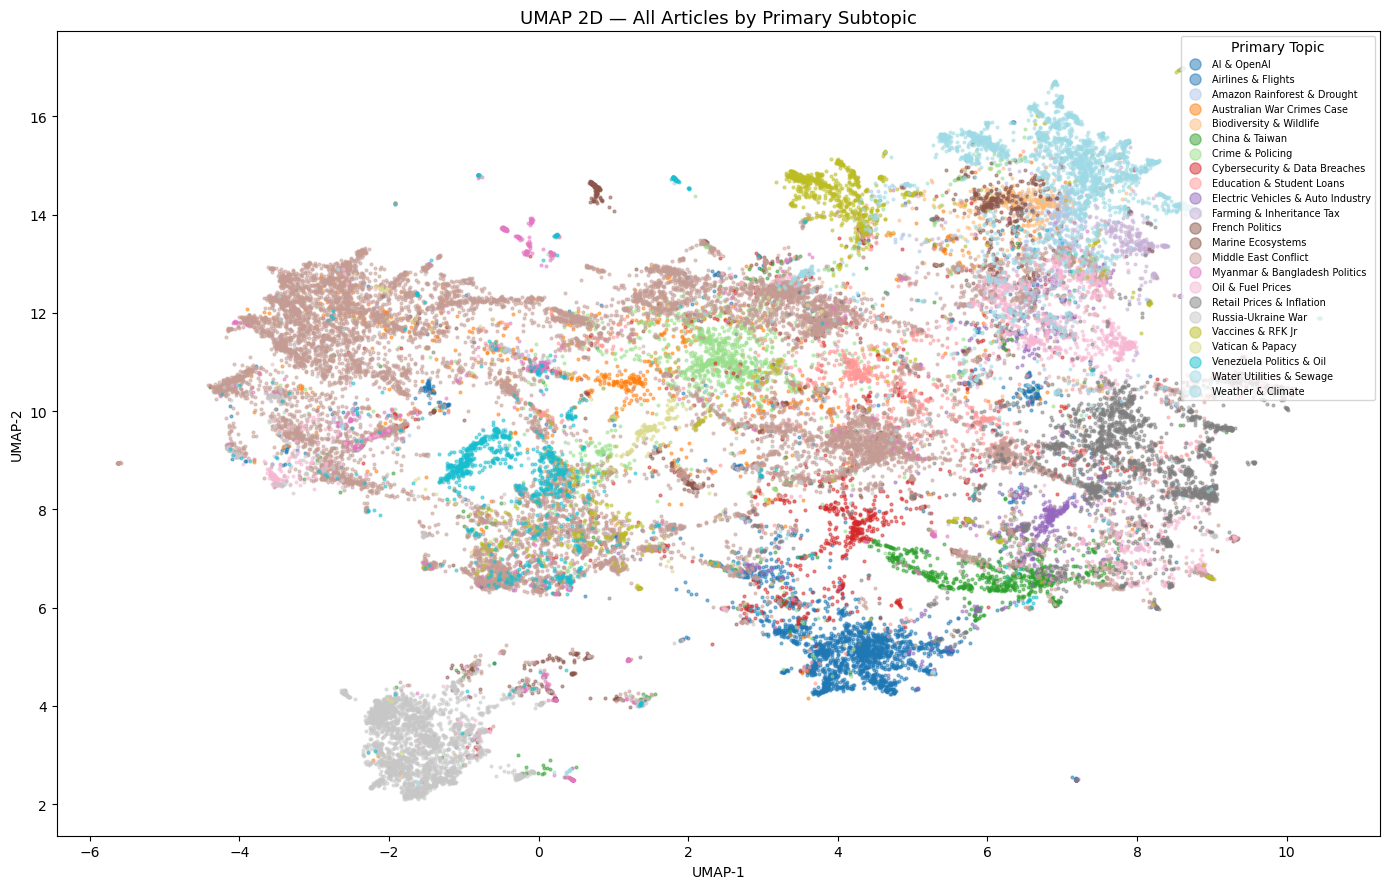

Saved: data/topic_clusters_umap.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from umap import UMAP as UMAP2D

reducer_2d = UMAP2D(n_components=2, metric='cosine', random_state=42, verbose=False)
emb_2d = reducer_2d.fit_transform(embeddings)

# Use primary label (first in subtopics list) for colouring
df['primary_label'] = df['subtopics'].apply(lambda x: x[0] if x else 'Unknown')
unique_labels = sorted(df['primary_label'].unique())
palette = cm.get_cmap('tab20', len(unique_labels))
color_map = {lbl: palette(i) for i, lbl in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(14, 9))
for lbl in unique_labels:
    mask = df['primary_label'] == lbl
    ax.scatter(
        emb_2d[mask, 0], emb_2d[mask, 1],
        s=4, alpha=0.5, color=color_map[lbl], label=lbl,
    )
ax.legend(loc='upper right', fontsize=7, markerscale=4, title='Primary Topic')
ax.set_title('UMAP 2D — All Articles by Primary Subtopic', fontsize=13)
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
plt.tight_layout()
plt.savefig('data/topic_clusters_umap.png', dpi=150)
plt.show()
print('Saved: data/topic_clusters_umap.png')

## Step 8 — Save Outputs

In [20]:
# Save classified articles (same schema as before — drop internal cols)
keep_cols = ['id', 'date', 'section', 'headline', 'body', 'wordcount', 'url', 'subtopic']
df_out = df_exp[keep_cols].copy()
df_out.to_csv('data/classified_articles.csv', index=False)
print(f'Saved: data/classified_articles.csv  ({len(df_out):,} rows)')

# Save topic info for reference / report
topic_summary = (
    topic_info[topic_info['Topic'] >= 0]
    .copy()
    .assign(name=lambda d: d['Topic'].apply(lookup_name))
    [['Topic', 'name', 'Count', 'Representation']]
    .rename(columns={'Topic': 'topic_id', 'name': 'subtopic_name', 'Count': 'articles_primary'})
)
topic_summary.to_csv('data/topic_info.csv', index=False)
print('Saved: data/topic_info.csv')

# Final subtopic distribution (unique articles per subtopic)
dist = (
    df_out.drop_duplicates(subset=['id', 'subtopic'])
    .groupby('subtopic')['id'].count()
    .sort_values(ascending=False)
    .rename('article_count')
)
print('\nFinal subtopic distribution:')
print(dist.to_string())

Saved: data/classified_articles.csv  (103,343 rows)
Saved: data/topic_info.csv

Final subtopic distribution:
subtopic
Middle East Conflict                 24263
Venezuela Politics & Oil              6470
Russia-Ukraine War                    6238
Australian War Crimes Case            5464
Oil & Fuel Prices                     5438
Cybersecurity & Data Breaches         5048
Retail Prices & Inflation             4677
Education & Student Loans             4581
Crime & Policing                      4085
Weather & Climate                     3810
Myanmar & Bangladesh Politics         3788
French Politics                       3772
China & Taiwan                        3757
AI & OpenAI                           3278
Electric Vehicles & Auto Industry     2767
Vaccines & RFK Jr                     2636
Farming & Inheritance Tax             2627
Airlines & Flights                    2430
Water Utilities & Sewage              2102
Amazon Rainforest & Drought           2047
Marine Ecosystems     

In [ ]:
# Step 9 — Add Entities + Risk Score (Phase 2)
import re

COUNTRY_TERMS = [
    'united states', 'us', 'israel', 'iran', 'uk', 'russia', 'china',
    'india', 'ukraine', 'taiwan', 'saudi arabia', 'qatar'
]
ORG_TERMS = [
    'opec', 'who', 'un', 'nato', 'eu', 'federal reserve', 'ecb',
    'openai', 'google', 'microsoft', 'meta', 'apple'
]
COMMODITY_TERMS = [
    'oil', 'crude', 'brent', 'natural gas', 'lng', 'lithium',
    'copper', 'nickel', 'uranium', 'wheat'
]
RISK_WEIGHTS = {
    'war': 4, 'missile': 3, 'airstrike': 3, 'sanctions': 2, 'military': 2,
    'cyberattack': 3, 'ransomware': 3, 'data breach': 2,
    'outbreak': 3, 'pandemic': 4,
    'oil': 2, 'shipping disruption': 3, 'supply chain': 2,
    'flood': 2, 'heatwave': 2, 'drought': 2, 'wildfire': 2,
    'recession': 3, 'inflation': 2, 'bank stress': 2,
}


def extract_terms(text: str, terms: list) -> str:
    t = str(text).lower()
    hits = [term for term in terms if re.search(rf'\\b{re.escape(term)}\\b', t)]
    return '|'.join(sorted(set(hits)))


def risk_score(text: str) -> int:
    t = str(text).lower()
    score = 0
    for term, weight in RISK_WEIGHTS.items():
        if re.search(rf'\\b{re.escape(term)}\\b', t):
            score += weight
    return min(score, 10)

# Backward-compatible: if older data lacks topic columns, create them.
if 'topics' not in df_exp.columns:
    df_exp['topics'] = ''
if 'primary_topic' not in df_exp.columns:
    df_exp['primary_topic'] = 'other'

keep_cols = [
    'id', 'date', 'section', 'headline', 'body', 'wordcount', 'url',
    'subtopic', 'topics', 'primary_topic'
]
df_enriched = df_exp[keep_cols].copy()

df_enriched['text_for_features'] = (
    df_enriched['headline'].fillna('') + ' ' + df_enriched['body'].fillna('')
)
df_enriched['countries'] = df_enriched['text_for_features'].apply(lambda x: extract_terms(x, COUNTRY_TERMS))
df_enriched['organizations'] = df_enriched['text_for_features'].apply(lambda x: extract_terms(x, ORG_TERMS))
df_enriched['commodities'] = df_enriched['text_for_features'].apply(lambda x: extract_terms(x, COMMODITY_TERMS))
df_enriched['risk_score'] = df_enriched['text_for_features'].apply(risk_score)
df_enriched = df_enriched.drop(columns=['text_for_features'])

df_enriched.to_csv('data/classified_articles.csv', index=False)
print(f'Saved enriched: data/classified_articles.csv ({len(df_enriched):,} rows)')

print('\nRisk score distribution:')
print(df_enriched['risk_score'].value_counts().sort_index().to_string())

print('\nSample enriched rows:')
print(df_enriched[['headline', 'primary_topic', 'countries', 'organizations', 'commodities', 'risk_score']].head(5).to_string(index=False))

Saved enriched: data/classified_articles.csv (103,343 rows)

Risk score distribution:
risk_score
0    103343

Sample enriched rows:
                                                                     headline        primary_topic countries organizations commodities  risk_score
Middle East crisis pushes up oil prices – and could drive inflation rises too                   ai                                               0
Middle East crisis pushes up oil prices – and could drive inflation rises too                   ai                                               0
Middle East crisis pushes up oil prices – and could drive inflation rises too                   ai                                               0
   Will shipping in the strait of Hormuz – and oil prices – return to normal? geopolitics_conflict                                               0
   Will shipping in the strait of Hormuz – and oil prices – return to normal? geopolitics_conflict                                   